# Perceptron

Binary classification on the California housing dataset: predict whether a block's median house value is above the overall median.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

data_df = pd.read_csv("housing.csv")
data_df['total_bedrooms'] = data_df['total_bedrooms'].fillna(data_df['total_bedrooms'].median())
data_df = pd.get_dummies(data_df, columns=['ocean_proximity'], dtype=float)

threshold = data_df['median_house_value'].median()
y = (data_df['median_house_value'] > threshold).astype(int).to_numpy()
X = data_df.drop(columns=['median_house_value']).to_numpy()

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, shuffle=True, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(np.bincount(y_train), np.bincount(y_test))

(13828, 13) (6812, 13)
[6916 6912] [3407 3405]


## Baseline

sklearn `Perceptron` with defaults as the reference. Linear classifier, so it'll struggle wherever the boundary really isn't linear.

In [2]:
clf = Perceptron(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Iterations: {clf.n_iter_}")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=['Below', 'Above']))

Accuracy: 0.8230
Iterations: 7
[[2717  690]
 [ 516 2889]]
              precision    recall  f1-score   support

       Below       0.84      0.80      0.82      3407
       Above       0.81      0.85      0.83      3405

    accuracy                           0.82      6812
   macro avg       0.82      0.82      0.82      6812
weighted avg       0.82      0.82      0.82      6812



## Learning rate sweep

Train with a range of `eta0` (η) values. Perceptron update on a misclassification:

$$w \leftarrow w + \eta (y - \hat y) x$$

Small η = slow but stable, large η = bouncy and may not settle near the boundary.

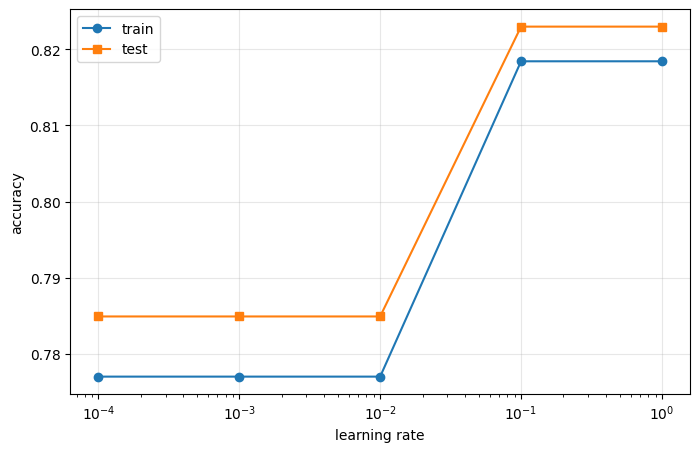

eta=0.0001   train=0.7770 test=0.7849
eta=0.001    train=0.7770 test=0.7849
eta=0.01     train=0.7770 test=0.7849
eta=0.1      train=0.8184 test=0.8230
eta=1.0      train=0.8184 test=0.8230


In [3]:
etas = [0.0001, 0.001, 0.01, 0.1, 1.0]
train_acc = []
test_acc = []

for eta in etas:
    m = Perceptron(eta0=eta, max_iter=1000, tol=1e-3, random_state=42)
    m.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, m.predict(X_train)))
    test_acc.append(accuracy_score(y_test, m.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.semilogx(etas, train_acc, 'o-', label='train')
plt.semilogx(etas, test_acc, 's-', label='test')
plt.xlabel('learning rate')
plt.ylabel('accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

for e, tr, te in zip(etas, train_acc, test_acc):
    print(f"eta={e:<8} train={tr:.4f} test={te:.4f}")

## From-scratch implementation

Pure-numpy perceptron — same update rule as `src/rice_ml/supervised_ml/perceptron.py`. Should land within a few points of sklearn since the algorithm is essentially the same.

Scratch train acc: 0.7734
Scratch test acc:  0.7829


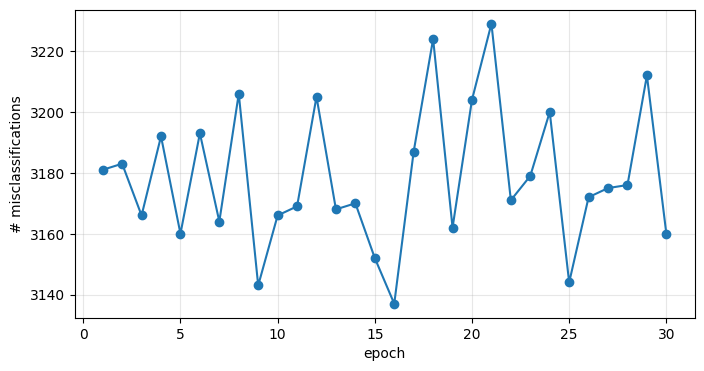

In [4]:
from rice_ml.supervised_ml import Perceptron as PerceptronScratch

scratch = PerceptronScratch(eta=0.01, epochs=30).fit(X_train, y_train)
print(f"Scratch train acc: {accuracy_score(y_train, scratch.predict(X_train)):.4f}")
print(f"Scratch test acc:  {accuracy_score(y_test, scratch.predict(X_test)):.4f}")

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(scratch.errors_) + 1), scratch.errors_, 'o-')
plt.xlabel('epoch')
plt.ylabel('# misclassifications')
plt.grid(alpha=0.3)
plt.show()

## Decision boundary on two features

Drop down to two features (`median_income` + `housing_median_age`) so the boundary is plottable. Lets me actually see what the perceptron learned — should be a single straight line cutting through the scatter.

2-feature test acc: 0.6885


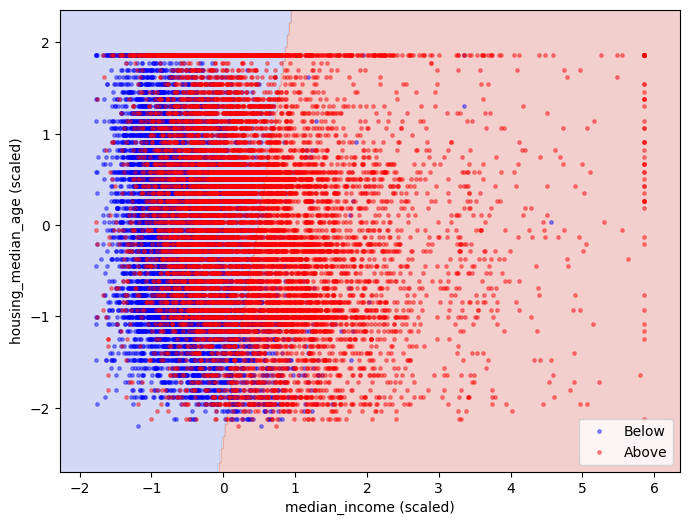

In [5]:
raw = pd.read_csv("housing.csv")
raw['total_bedrooms'] = raw['total_bedrooms'].fillna(raw['total_bedrooms'].median())
thr = raw['median_house_value'].median()
y2 = (raw['median_house_value'] > thr).astype(int).to_numpy()
X2 = raw[['median_income', 'housing_median_age']].to_numpy()
X2 = StandardScaler().fit_transform(X2)

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.33, random_state=42, stratify=y2
)

m2 = Perceptron(random_state=42).fit(X2_train, y2_train)
print(f"2-feature test acc: {accuracy_score(y2_test, m2.predict(X2_test)):.4f}")

xx, yy = np.meshgrid(
    np.linspace(X2[:, 0].min() - 0.5, X2[:, 0].max() + 0.5, 300),
    np.linspace(X2[:, 1].min() - 0.5, X2[:, 1].max() + 0.5, 300),
)
Z = m2.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
plt.scatter(X2[y2 == 0, 0], X2[y2 == 0, 1], s=6, c='blue', alpha=0.4, label='Below')
plt.scatter(X2[y2 == 1, 0], X2[y2 == 1, 1], s=6, c='red', alpha=0.4, label='Above')
plt.xlabel('median_income (scaled)')
plt.ylabel('housing_median_age (scaled)')
plt.legend()
plt.show()